# Лабораторная работа: Ансамбли моделей машинного обучения. Часть 1.
Панасюк Ксения ИУ5-64Б

Цель лабораторной работы: изучение ансамблей моделей машинного обучения

Задание:

        Выберите набор данных (датасет) для решения задачи классификации или регресии.
        В случае необходимости проведите удаление или заполнение пропусков и кодирование категориальных признаков.
        С использованием метода train_test_split разделите выборку на обучающую и тестовую.
        Обучите следующие ансамблевые модели:
            две модели группы бэггинга (бэггинг или случайный лес или сверхслучайные деревья);
            AdaBoost;
            градиентный бустинг.
        Оцените качество моделей с помощью одной из подходящих для задачи метрик. Сравните качество полученных моделей.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score

In [3]:
# Загрузка датасета Был выбран датасет рака груди
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

# В данном датасете пропусков нет, кодирование категориальных признаков не требуется.
# Разделение выборки
X_train, X_test, y_train, y_test = train_test_split(df, y, test_size=0.3, random_state=42)

print(f"Размер обучающей выборки: {X_train.shape}")
print(f"Размер тестовой выборки: {X_test.shape}")

Размер обучающей выборки: (398, 30)
Размер тестовой выборки: (171, 30)


In [6]:
# Обучение моделей
# 1. Бэггинг: Случайный лес
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# 2. Бэггинг: Сверхслучайные деревья (Extra Trees)
et = ExtraTreesClassifier(n_estimators=100, random_state=42)
et.fit(X_train, y_train)

# 3. Бустинг: AdaBoost
ada = AdaBoostClassifier(n_estimators=100, random_state=42)
ada.fit(X_train, y_train)

# 4. Бустинг: Градиентный бустинг
gb = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb.fit(X_train, y_train)

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


Random Forest: Accuracy = 0.9708
Extra Trees: Accuracy = 0.9766
AdaBoost: Accuracy = 0.9708
Gradient Boosting: Accuracy = 0.9591


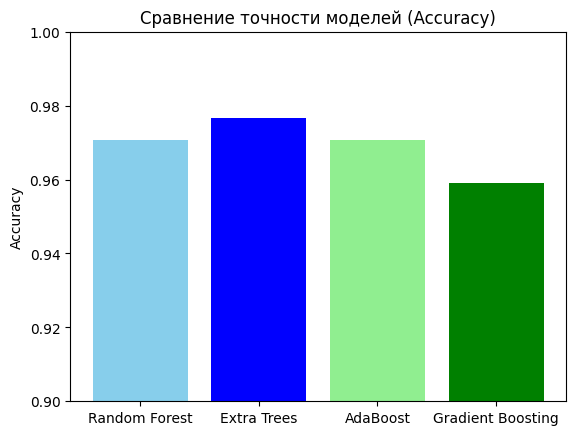

In [8]:
# сравнение качества
models = {
    "Random Forest": rf,
    "Extra Trees": et,
    "AdaBoost": ada,
    "Gradient Boosting": gb
}

results = {}

for name, model in models.items():
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    results[name] = acc
    print(f"{name}: Accuracy = {acc:.4f}")

# Визуализация результатов
plt.bar(results.keys(), results.values(), color=['skyblue', 'blue', 'lightgreen', 'green'])
plt.title("Сравнение точности моделей (Accuracy)")
plt.ylim(0.9, 1.0)
plt.ylabel("Accuracy")
plt.show()